# Ultra-Marathon Performance Visualization — Part B
### Speed Distributions & Performance Over Time

**Group 17** — Luiz Samelo, Maximilian Staudacher, Rayudu Muralikrishna

This notebook covers two visualizations focused on speed distributions and 
long-term performance trends in ultra-marathon running.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
cols_needed = ["Year of event", "Event distance/length", "Athlete average speed"]
distances_wanted = ["50km", "50mi", "100km"]
chunks = []

for chunk in pd.read_csv(
    "../data/TWO_CENTURIES_OF_UM_RACES.csv",
    usecols=cols_needed,
    chunksize=200_000,
    low_memory=False
):
    chunk = chunk[chunk["Event distance/length"].isin(distances_wanted)]
    chunk = chunk.dropna(subset=["Athlete average speed"])
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(df.shape)
print(df["Event distance/length"].value_counts())
print(df["Athlete average speed"].describe())

(2826531, 3)
Event distance/length
50km     1522608
100km     951742
50mi      352181
Name: count, dtype: int64
count     2826531
unique      47752
top         7.282
freq          903
Name: Athlete average speed, dtype: object


In [3]:
df["Athlete average speed"] = pd.to_numeric(df["Athlete average speed"], errors="coerce")
df = df.dropna(subset=["Athlete average speed"])

print(df.shape)
print(df["Athlete average speed"].describe())

(2826411, 3)
count    2.826411e+06
mean     7.514402e+02
std      2.476926e+03
min      1.920000e-01
25%      6.324000e+00
50%      7.720000e+00
75%      9.468000e+00
max      2.830200e+04
Name: Athlete average speed, dtype: float64


In [4]:
df = df[(df["Athlete average speed"] >= 2) & (df["Athlete average speed"] <= 20)]

print(df.shape)
print(df["Athlete average speed"].describe())

(2573579, 3)
count    2.573579e+06
mean     7.599998e+00
std      2.140008e+00
min      2.012000e+00
25%      6.171000e+00
50%      7.472000e+00
75%      8.858000e+00
max      1.989600e+01
Name: Athlete average speed, dtype: float64


### Visualization 3: Speed Distribution Across Ultra-Marathon Distances

This box plot shows finishing speed distributions across three ultra-marathon distances (50 km, 50 mi, 100 km),
filtered to post-1980 races. Distances are ordered by length so the speed drop reads left to right. Outlier dots
are hidden due to dataset size, and speeds outside 2–20 km/h were removed as data errors beforehand.

The 50 km races show the highest median and tightest spread, reflecting a more competitive field. The 100 km box
is noticeably wider what is consistent with a more mixed participation base.

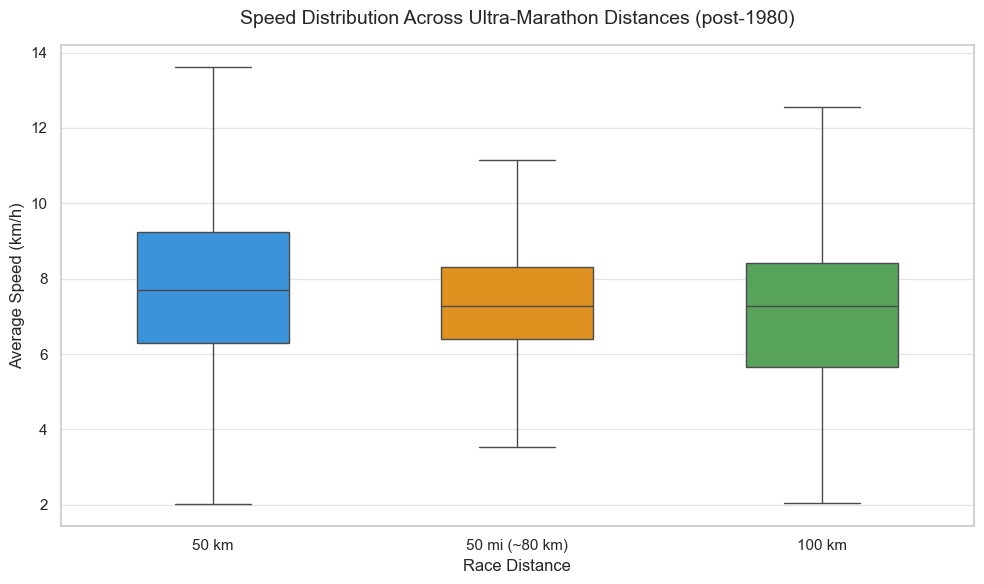

In [5]:
df_viz3 = df[df["Year of event"] >= 1980].copy()

distance_order = ["50km", "50mi", "100km"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_viz3,
    x="Event distance/length",
    y="Athlete average speed",
    order=distance_order,
    hue="Event distance/length",
    palette=["#2196F3", "#FF9800", "#4CAF50"],
    width=0.5,
    showfliers=False,
    legend=False,
    ax=ax
)

ax.set_title("Speed Distribution Across Ultra-Marathon Distances (post-1980)", fontsize=14, pad=15)
ax.set_xlabel("Race Distance", fontsize=12)
ax.set_ylabel("Average Speed (km/h)", fontsize=12)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["50 km", "50 mi (~80 km)", "100 km"])

plt.tight_layout()
plt.savefig("../Viz/viz3_boxplots_speed_by_distance.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 4: Elite vs. Median Performance in 50km Races Over Time

This line chart tracks the mean speed of the top 10 finishers per year against the overall median in 50 km races. Only years with at least 50 finishers are included, which is why the series starts around 1996. The shaded area highlights the gap between the two groups.

The elite line stays flat around 17–18 km/h throughout the period, while the median drops steadily from something close to 9.3 km/h in the late 90s to approximately 7.2 km/h by 2022. The widening gap supports our hypothesis, that is, as the sport grew, more recreational runners joined while the top performers held their level.

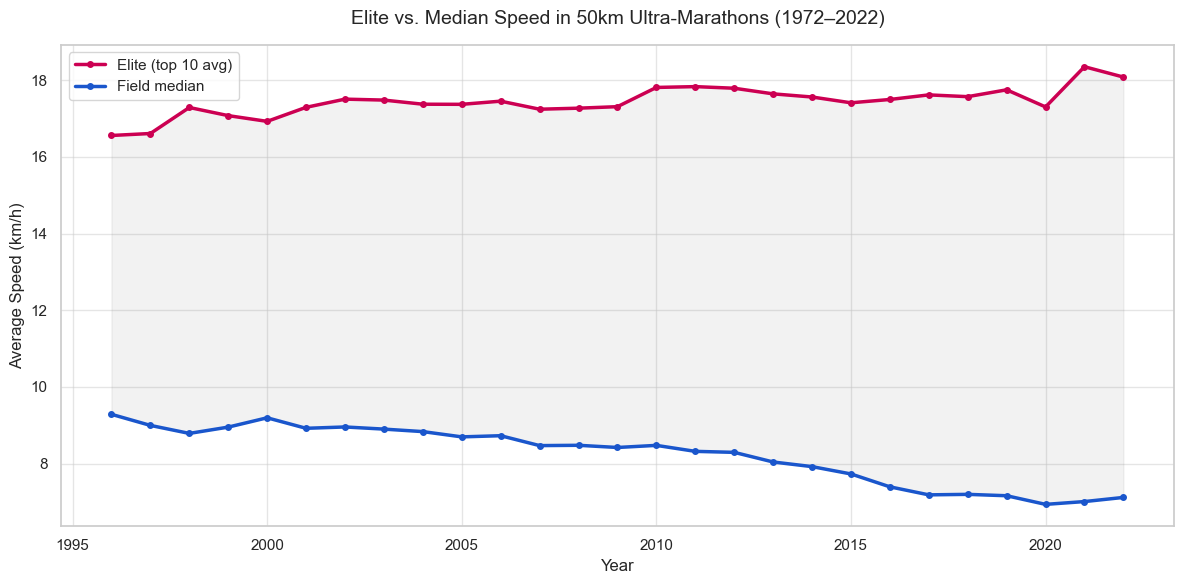

In [7]:

df_50k = df[
    (df["Event distance/length"] == "50km") &
    (df["Year of event"] >= 1972)
].copy()

yearly = df_50k.groupby("Year of event")["Athlete average speed"].agg(
    elite=lambda x: x.nlargest(10).mean() if len(x) >= 50 else np.nan,
    median=lambda x: x.median() if len(x) >= 50 else np.nan,
    count="count"
).reset_index()

yearly = yearly[yearly["count"] >= 50].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(yearly["Year of event"], yearly["elite"],
        color="#cc0052", linewidth=2.5, marker="o", markersize=4, label="Elite (top 10 avg)")
ax.plot(yearly["Year of event"], yearly["median"],
        color="#1a56cc", linewidth=2.5, marker="o", markersize=4, label="Field median")

ax.fill_between(yearly["Year of event"], yearly["elite"], yearly["median"],
                alpha=0.1, color="gray")

ax.set_title("Elite vs. Median Speed in 50km Ultra-Marathons (1972–2022)", fontsize=14, pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Speed (km/h)", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../Viz/viz4_elite_vs_median.png", dpi=150, bbox_inches="tight")
plt.show()